## Modelo de RL para optimización de trayectorias

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv

### Potenciales para entrenar la particula y función que calcula el gradiente numérico 

In [45]:
# def grad_potential(potential_fn, x, y, eps=1e-3):
#     dVdx = (potential_fn(x + eps, y) - potential_fn(x - eps, y)) / (2 * eps)
#     dVdy = (potential_fn(x, y + eps) - potential_fn(x, y - eps)) / (2 * eps)

#     grad = np.array([dVdx, dVdy], dtype=np.float32)

#     # normalización recomendada (muy importante en RL)
#     norm = np.linalg.norm(grad) + 1e-8
#     return grad / norm

# def V_sin_cos_1(x, y):
#     return np.sin(3*x)*np.cos(3*y)

# def V_sin_cos_2(x, y):
#     return 0.5*np.sin(5*x) + 0.5*np.cos(4*y)

# def V_sin_cos_mix(x, y):
#     return np.sin(3*x)*np.sin(3*y) + 0.3*(x**2 + y**2)

# def V_gauss_1(x, y):
#     centers = [(0.3,0.3), (0.7,0.6)]
#     V = 0.0
#     for cx, cy in centers:
#         r2 = (x-cx)**2 + (y-cy)**2
#         V -= np.exp(-r2 / (2*0.08**2))
#     return V

# def make_random_gaussians(n=3):
#     centers = np.random.uniform(0, 1, size=(n,2))
#     amps = np.random.uniform(0.5, 1.5, size=n)
#     sigmas = np.random.uniform(0.05, 0.15, size=n)

#     def V(x, y):
#         val = 0.0
#         for (cx, cy), A, s in zip(centers, amps, sigmas):
#             r2 = (x-cx)**2 + (y-cy)**2
#             val -= A * np.exp(-r2/(2*s**2))
#         return val

#     return V

# def V_mix_1(x, y):
#     return (
#         np.sin(3*x)*np.cos(3*y)
#         - np.exp(-((x-0.7)**2 + (y-0.3)**2)/0.02)
#     )
    
# def V_mix_2(x, y):
#     return (
#         0.3*(x**2 + y**2)
#         + np.sin(4*x)*np.sin(4*y)
#         - 1.2*np.exp(-((x-0.5)**2 + (y-0.5)**2)/0.01)
#     )



In [46]:

# def sample_potential():
#     options = [
#         V_sin_cos_1,
#         V_sin_cos_2,
#         V_sin_cos_mix,
#         V_gauss_1,
#         V_mix_1,
#         V_mix_2,
#         make_random_gaussians()
#     ]
#     return np.random.choice(options)


# # ====== entorno ======
# class ParticlePotentialEnv(gym.Env):
#     metadata = {"render_modes": ["human"]}

#     def __init__(
#         self,
#         potential_fn=None,
#         max_steps=1000,
#         dt=0.02,
#         speed=0.25,
#         goal_radius=0.02,
#         render_mode=None,
#         x_max=1.0,
#         y_max=1.0,
#     ):
#         super().__init__()

#         # si no pasas potencial → se muestrea en reset()
#         self.potential_fn = potential_fn
#         self.max_steps = max_steps
#         self.dt = dt
#         self.speed = speed
#         self.goal_radius = goal_radius
#         self.render_mode = render_mode

#         self.x_max = x_max
#         self.y_max = y_max

#         # acción: ángulo en [-pi, pi] parametrizado en [-1,1]
#         self.action_space = spaces.Box(
#             low=-1.0, high=1.0, shape=(1,), dtype=np.float32
#         )

#         # obs = [x, y, dx_goal, dy_goal, V, gradVx, gradVy]
#         self.observation_space = spaces.Box(
#             low=np.array([0, 0, -1, -1, -2, -1, -1], dtype=np.float32),
#             high=np.array([self.x_max, self.y_max, 1, 1, 2, 1, 1], dtype=np.float32),
#             dtype=np.float32,
#         )

#         self.pos = None
#         self.goal = None
#         self.steps = 0
#         self.traj = []

#     # -------- observación --------
#     def _obs(self):
#         V = self.potential_fn(self.pos[0], self.pos[1])
#         V = np.clip(V, -2.0, 2.0)  # estabiliza

#         gradV = grad_potential(self.potential_fn, self.pos[0], self.pos[1])

#         return np.concatenate(
#             [self.pos, self.goal - self.pos, [V], gradV]
#         ).astype(np.float32)

#     # -------- reset --------
#     def reset(self, seed=None, options=None):
#         super().reset(seed=seed)

#         # muestrea potencial si no está fijado
#         if self.potential_fn is None:
#             self.potential_fn = sample_potential()

#         self.pos = self.np_random.uniform(
#             [0, 0], [self.x_max, self.y_max]
#         ).astype(np.float32)

#         self.goal = self.np_random.uniform(
#             [0, 0], [self.x_max, self.y_max]
#         ).astype(np.float32)

#         self.steps = 0
#         self.traj = [self.pos.copy()]

#         return self._obs(), {}

#     # -------- step --------
#     def step(self, action):
#         action = np.clip(action, -1, 1)
#         theta = float(action[0] * np.pi)

#         prev_pos = self.pos.copy()

#         direction = np.array(
#             [np.cos(theta), np.sin(theta)], dtype=np.float32
#         )

#         self.pos += self.speed * direction * self.dt
#         self.steps += 1
#         self.traj.append(self.pos.copy())

#         # ---- métricas geométricas ----
#         vec_to_goal = self.goal - self.pos
#         dist = np.linalg.norm(vec_to_goal)
#         prev_dist = np.linalg.norm(self.goal - prev_pos)

#         r_progress = (prev_dist - dist)

#         if dist > 1e-8:
#             dir_to_goal = vec_to_goal / dist
#             r_align = np.dot(direction, dir_to_goal)
#         else:
#             r_align = 0.0

#         # ---- potencial ----
#         V = self.potential_fn(self.pos[0], self.pos[1])
#         V = np.clip(V, -2.0, 2.0)

#         gradV = grad_potential(self.potential_fn, self.pos[0], self.pos[1])

#         # ---- reward estable ----
#         r_potential = -0.1 * V
#         r_slope = -np.dot(direction, gradV)
#         r_step = -0.005

#         reward = (
#             3.0 * r_progress
#             + 0.3 * r_align
#             + r_potential
#             + 0.5 * r_slope
#             + r_step
#         )

#         # ---- terminales ----
#         terminated = dist < self.goal_radius
#         if terminated:
#             reward += 20.0

#         out = np.any(
#             (self.pos < 0.0) | (self.pos > [self.x_max, self.y_max])
#         )
#         if out:
#             reward -= 20.0

#         truncated = (self.steps >= self.max_steps) or out

#         info = {"distance": dist}

#         return self._obs(), reward, terminated, truncated, info

In [47]:
# def make_env():
#     return ParticlePotentialEnv(potential_fn=None) 

# env = DummyVecEnv([make_env])

# model = SAC(
#     "MlpPolicy",
#     env,
#     learning_rate=3e-4,
#     gamma=0.995,
#     ent_coef="auto",
#     batch_size=256,
#     verbose=1,
# )

# model.learn(50_000, progress_bar= True)

# model.save('SAC_potenciales')

In [48]:
# import os
# import subprocess
# import webbrowser
# import time
# import numpy as np

# from stable_baselines3.common.monitor import Monitor
# from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
# from stable_baselines3.common.callbacks import BaseCallback
# from stable_baselines3 import SAC

# def launch_tensorboard(logdir="./tb_logs", port=6006, open_browser=True):
#     cmd = ["tensorboard", f"--logdir={logdir}", f"--port={port}"]
#     proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
#     if open_browser:
#         time.sleep(3)  # espera a que levante
#         webbrowser.open(f"http://localhost:{port}")
#     return proc

# class EvalMetricsCallback(BaseCallback):
#     def __init__(self, eval_env_fn, eval_freq=5000, n_eval_episodes=10):
#         super().__init__()
#         self.eval_env_fn = eval_env_fn
#         self.eval_freq = eval_freq
#         self.n_eval_episodes = n_eval_episodes

#     def _rollout_episode(self, env):
#         obs, _ = env.reset()
#         done = False
#         total_r = 0.0
#         steps = 0
#         energy = 0.0

#         while not done:
#             action, _ = self.model.predict(obs, deterministic=True)
#             obs, r, term, trunc, _ = env.step(action)
#             total_r += r
#             steps += 1
#             # energía acumulada (usa el mismo potencial del env)
#             V = env.potential_fn(env.pos[0], env.pos[1])
#             energy += V
#             done = term or trunc

#         success = float(term)
#         return total_r, steps, energy, success

#     def _on_step(self):
#         if self.n_calls % self.eval_freq != 0:
#             return True

#         env = self.eval_env_fn()
#         rewards, lengths, energies, successes = [], [], [], []

#         for _ in range(self.n_eval_episodes):
#             r, L, E, S = self._rollout_episode(env)
#             rewards.append(r)
#             lengths.append(L)
#             energies.append(E)
#             successes.append(S)

#         self.logger.record("eval/mean_reward", np.mean(rewards))
#         self.logger.record("eval/success_rate", np.mean(successes))
#         self.logger.record("eval/mean_length", np.mean(lengths))
#         self.logger.record("eval/mean_energy", np.mean(energies))

#         return True
    
# def make_train_env():
#     env = make_env()                     # tu función
#     return Monitor(env)                  # registra ep_rew, ep_len

# def make_vec_env(n=1):
#     env = DummyVecEnv([make_train_env for _ in range(n)])
#     env = VecMonitor(env)                # logging a TB
#     return env

# def make_eval_env():
#     return make_env()                    # sin VecEnv, para callback

In [49]:
# from stable_baselines3.common.monitor import Monitor


# # TRAIN 
# def make_env():
#     return Monitor(ParticlePotentialEnv())

# env = DummyVecEnv([make_env])
# eval_env = ParticlePotentialEnv()


# model = SAC(
#     "MlpPolicy",
#     env,
#     learning_rate=3e-4,
#     gamma=0.995,
#     batch_size=256,
#     ent_coef="auto",
#     verbose=1
# )

# print('Entrenando')
# model.learn(50_000)
# print('Fin')

# model.save('SAC_potenciales')

In [2]:
# --- Gaussianas (vectorizado y con gradiente) ---
def make_gaussians_with_grad(n=3):
    centers = np.random.uniform(0, 1, size=(n, 2))
    amps = np.random.uniform(0.5, 1.5, size=n)
    sigmas = np.random.uniform(0.05, 0.15, size=n)

    def V(x, y):
        dx = x - centers[:,0]
        dy = y - centers[:,1]
        r2 = dx*dx + dy*dy
        return -np.sum(amps * np.exp(-r2/(2*sigmas**2)))

    def gradV(x, y):
        dx = x - centers[:,0]
        dy = y - centers[:,1]
        r2 = dx*dx + dy*dy

        exp_term = np.exp(-r2/(2*sigmas**2))
        coeff = amps * exp_term / (sigmas**2)

        gx = np.sum(coeff * dx)
        gy = np.sum(coeff * dy)

        grad = np.array([gx, gy], dtype=np.float32)
        return grad / (np.linalg.norm(grad) + 1e-8)

    return V, gradV


# --- Seno/coseno ---
def make_sin_with_grad():
    def V(x, y):
        return np.sin(3*x)*np.cos(3*y)

    def gradV(x, y):
        gx = 3*np.cos(3*x)*np.cos(3*y)
        gy = -3*np.sin(3*x)*np.sin(3*y)
        grad = np.array([gx, gy], dtype=np.float32)
        return grad / (np.linalg.norm(grad) + 1e-8)

    return V, gradV


# --- sampler ---
def sample_potential():
    if np.random.rand() < 0.5:
        return make_gaussians_with_grad()
    else:
        return make_sin_with_grad()

In [3]:

class FastGradEnv(gym.Env):
    def __init__(self, max_steps=250):
        super().__init__()

        self.max_steps = max_steps
        self.dt = 0.02
        self.speed = 0.25

        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)

        # obs: pos (2) + goal vec (2) + V (1) + grad (2)
        self.observation_space = spaces.Box(
            low=np.array([0,0,-1,-1,-2,-1,-1]),
            high=np.array([1,1,1,1,2,1,1]),
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.V_fn, self.grad_fn = sample_potential()

        self.pos = self.np_random.uniform(0,1,2).astype(np.float32)
        self.goal = self.np_random.uniform(0,1,2).astype(np.float32)

        self.steps = 0
        return self._obs(), {}

    def _obs(self):
        V = np.clip(self.V_fn(self.pos[0], self.pos[1]), -2, 2)
        grad = self.grad_fn(self.pos[0], self.pos[1])

        return np.concatenate([
            self.pos,
            self.goal - self.pos,
            [V],
            grad
        ]).astype(np.float32)

    def step(self, action):
        theta = float(action[0] * np.pi)
        direction = np.array([np.cos(theta), np.sin(theta)], dtype=np.float32)

        prev_pos = self.pos.copy()
        self.pos += self.speed * direction * self.dt
        self.steps += 1

        dist = np.linalg.norm(self.goal - self.pos)
        prev_dist = np.linalg.norm(self.goal - prev_pos)

        # señales
        r_progress = prev_dist - dist
        r_align = np.dot(direction, (self.goal-self.pos)/(dist+1e-8))

        V = np.clip(self.V_fn(self.pos[0], self.pos[1]), -2, 2)
        grad = self.grad_fn(self.pos[0], self.pos[1])

        r_slope = -np.dot(direction, grad)

        reward = (
            8.0 * r_progress +
            1.0 * r_align +
            0.5 * r_slope -
            0.05 * V -
            0.01
        )

        terminated = dist < 0.02
        if terminated:
            reward += 20

        truncated = self.steps >= self.max_steps

        return self._obs(), reward, terminated, truncated, {}

In [4]:
env = DummyVecEnv([lambda: FastGradEnv()])

# quitar para entrenar
# model = SAC(
#     "MlpPolicy",
#     env,
#     learning_rate=3e-4,
#     gamma=0.995,
#     batch_size=256,
#     ent_coef="auto",
#     verbose=1
# )

# model.learn(300_000, reset_num_timesteps= False)

In [8]:
# model.save('SAC_potenciales1')
model = SAC.load(path='modelo_sb3.zip')

In [12]:
def evaluate(model, env, n_episodes=20):
    rewards, lengths, energies, successes, effs = [], [], [], [], []

    for _ in range(n_episodes):
        obs,_ = env.reset()
        traj = [env.pos.copy()]
        total_r = 0
        energy = 0

        done = False
        term = False

        while not done:
            action,_ = model.predict(obs.reshape(1, -1), deterministic=True)
            action = action[0]

            obs,r,term,trunc,_ = env.step(action)

            total_r += r
            energy += env.V_fn(env.pos[0], env.pos[1])

            traj.append(env.pos.copy())
            done = term or trunc

        traj = np.array(traj)

        path_length = np.sum(np.linalg.norm(np.diff(traj, axis=0), axis=1))
        direct_dist = np.linalg.norm(traj[0] - env.goal)

        rewards.append(total_r)
        lengths.append(len(traj))
        energies.append(energy)
        successes.append(float(term))
        effs.append(direct_dist / (path_length + 1e-8))

    return {
        "reward": float(np.mean(rewards)),
        "success": float(np.mean(successes)),
        "length": float(np.mean(lengths)),
        "energy": float(np.mean(energies)),
        "efficiency": float(np.mean(effs))
    }

results = evaluate(model, FastGradEnv(), n_episodes=20)
print(results)

{'reward': 64.52887572478296, 'success': 0.7, 'length': 147.6, 'energy': -38.5976689688447, 'efficiency': 0.7764462232589722}


### Evaluamos con un potencial no visto

In [30]:
def V_test(x, y):
    return (
        0.4*np.sin(5*x) * np.cos(4*y)
        + 0.3*np.sin(2*x + y)
        + np.exp(-((x-0.2)**2 + (y-0.8)**2)/0.01)
        - 1.2*np.exp(-((x-0.7)**2 + (y-0.3)**2)/0.02)
    )

def grad_test(x, y):
    gx = (
        0.4*5*np.cos(5*x)*np.cos(4*y)
        + 0.3*2*np.cos(2*x + y)
        + ((x-0.2)/0.01)*np.exp(-((x-0.2)**2 + (y-0.8)**2)/0.01)
        - 1.2*((x-0.7)/0.02)*np.exp(-((x-0.7)**2 + (y-0.3)**2)/0.02)
    )

    gy = (
        -0.4*4*np.sin(5*x)*np.sin(4*y)
        + 0.3*np.cos(2*x + y)
        + ((y-0.8)/0.01)*np.exp(-((x-0.2)**2 + (y-0.8)**2)/0.01)
        - 1.2*((y-0.3)/0.02)*np.exp(-((x-0.7)**2 + (y-0.3)**2)/0.02)
    )

    grad = np.array([gx, gy], dtype=np.float32)
    return grad / (np.linalg.norm(grad) + 1e-8)

class TestEnv(FastGradEnv):
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.V_fn = V_test
        self.grad_fn = grad_test

        # opcional: evitar casos imposibles
        while True:
            self.pos = self.np_random.uniform(0,1,2)
            self.goal = self.np_random.uniform(0,1,2)
            if np.linalg.norm(self.goal - self.pos) < 0.7:
                break

        return self._obs(), {}
    

results = evaluate(model, TestEnv(), n_episodes=100)
print(results)

{'reward': 64.00642957615304, 'success': 0.74, 'length': 135.34, 'energy': 16.130309959370702, 'efficiency': 0.7709987354037992}


In [31]:
# ===== función de test con gráfica =====
def test_and_plot(model, env):
    obs,_ = env.reset()

    traj = [env.pos.copy()]
    done = False

    while not done:
        action,_ = model.predict(obs.reshape(1, -1), deterministic=True)
        action = action[0]

        obs,_,term,trunc,_ = env.step(action)
        traj.append(env.pos.copy())

        done = term or trunc

    traj = np.array(traj)

    # ===== crear mapa del potencial =====
    res = 200
    xs = np.linspace(0,1,res)
    ys = np.linspace(0,1,res)
    X, Y = np.meshgrid(xs, ys)

    Z = np.zeros_like(X)
    for i in range(res):
        for j in range(res):
            Z[i,j] = env.V_fn(X[i,j], Y[i,j])

    # ===== plot =====
    plt.figure(figsize=(8,8))

    plt.imshow(Z, origin="lower", extent=[0,1,0,1], cmap="terrain")
    plt.colorbar(label="Potencial")

    # trayectoria
    plt.plot(traj[:,0], traj[:,1], "w-", linewidth=2, label="Trayectoria")

    # inicio y meta
    plt.scatter(traj[0,0], traj[0,1], c="blue", s=80, label="Inicio")
    plt.scatter(env.goal[0], env.goal[1], c="red", s=120, marker="*", label="Meta")

    plt.title(f"Trayectoria (steps={len(traj)})")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return traj



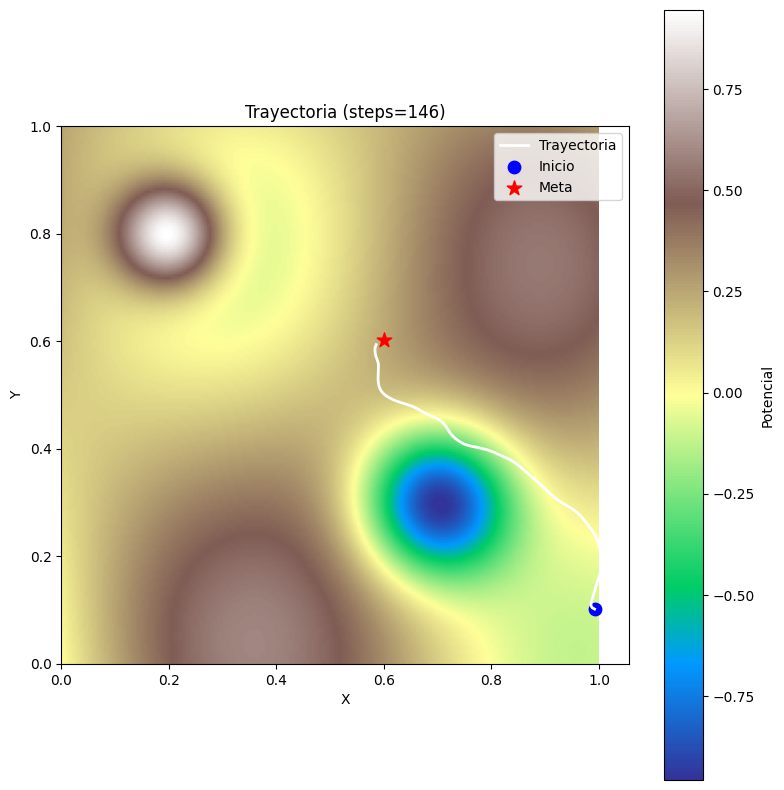

In [32]:
env = TestEnv()
traj = test_and_plot(model, env)